#Iris Datset

In [1]:
import sys
import scipy
import numpy
import matplotlib
import pandas
import sklearn

print('Python: {}'.format(sys.version))
print('scipy: {}'.format(scipy.__version__))
print('numpy: {}'.format(numpy.__version__))
print('matplotlib: {}'.format(matplotlib.__version__))
print('pandas: {}'.format(pandas.__version__))
print('sklearn: {}'.format(sklearn.__version__))

Python: 3.6.6 |Anaconda, Inc.| (default, Oct  9 2018, 12:34:16) 
[GCC 7.3.0]
scipy: 1.1.0
numpy: 1.16.3
matplotlib: 3.0.3
pandas: 0.23.4
sklearn: 0.20.3


## 1. Import libraries

Import all of the modules, functions, and objects we will use in this tutorial.

In [2]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

## 2. Load the Dataset

We will be using the iris flowers dataset, which contains 150 observations of iris flowers. There are four columns of measurements and the species of flower observed.  Only three species are present in this dataset.

The data can be loaded directly from the UCI Machine Learning Repository

In [8]:
# Load Dataset
dataset=pandas.read_csv('../input/Iris.csv')

## 2.1 Dataset Properties

Lets take a look at the dataset by observing its dimensions, the first few rows of data, a statistical summary of the attributes, and a breakdown of the data by the class variable.

In [17]:
del dataset['Id']

In [18]:
# Shape
print(dataset.shape)

(150, 5)


In [19]:
# Head
print(dataset.head(20))

    SepalLengthCm  SepalWidthCm     ...       PetalWidthCm      Species
0             5.1           3.5     ...                0.2  Iris-setosa
1             4.9           3.0     ...                0.2  Iris-setosa
2             4.7           3.2     ...                0.2  Iris-setosa
3             4.6           3.1     ...                0.2  Iris-setosa
4             5.0           3.6     ...                0.2  Iris-setosa
5             5.4           3.9     ...                0.4  Iris-setosa
6             4.6           3.4     ...                0.3  Iris-setosa
7             5.0           3.4     ...                0.2  Iris-setosa
8             4.4           2.9     ...                0.2  Iris-setosa
9             4.9           3.1     ...                0.1  Iris-setosa
10            5.4           3.7     ...                0.2  Iris-setosa
11            4.8           3.4     ...                0.2  Iris-setosa
12            4.8           3.0     ...                0.1  Iris

In [20]:
# descriptions
print(dataset.describe())

       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.900000      4.400000       6.900000      2.500000


In [21]:
# class distribution
print(dataset.groupby('Species').mean())

                 SepalLengthCm      ...       PetalWidthCm
Species                             ...                   
Iris-setosa              5.006      ...              0.244
Iris-versicolor          5.936      ...              1.326
Iris-virginica           6.588      ...              2.026

[3 rows x 4 columns]


In [22]:
print(dataset.groupby('Species').size())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64


In [23]:
print(dataset.groupby('Species').median())

                 SepalLengthCm      ...       PetalWidthCm
Species                             ...                   
Iris-setosa                5.0      ...                0.2
Iris-versicolor            5.9      ...                1.3
Iris-virginica             6.5      ...                2.0

[3 rows x 4 columns]


## 2.2 Data Visualizations

Lets visualize the data so we can understand the distribution of the input attributes. We will use histograms of each attribute, as well as some multivariate plots so that we can view the interactions between variables.

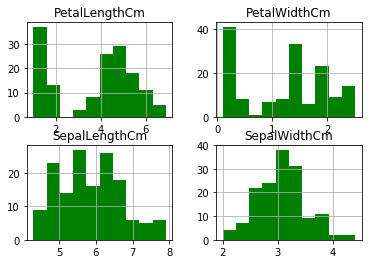

In [24]:
# histograms
dataset.hist(color='green')
plt.show()

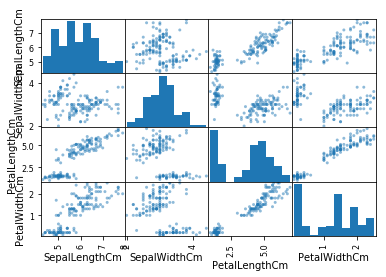

In [25]:
# scatter plot matrix
scatter_matrix(dataset)
plt.show()

## 3. Evaluate Algorithms

Lets create some models of the data and estimate their accuracy on unseen data.

We are going to,

* Create a validation dataset
* Set-up cross validation
* Build three different models to predict species from flower measurement
* Select the best model

## 3.1 Create Validation Dataset

Lets split the loaded dataset into two.  80% of the data will be used for training, while 20% will be used for validation.

In [27]:
# Split-out validation dataset
array = dataset.values
X = array[:,0:4]
Y = array[:,4]
validation_size = 0.30
seed = 7
X_train, X_validation, Y_train, Y_validation = model_selection.train_test_split(X, Y, test_size = validation_size, random_state = seed)

## 3.2 10-fold Cross Validation

This will split our dataset into 10 parts, train on 9 and test on 1 and repeate for all combinations of train-test splits

In [28]:
# Test options and evaluation metric
seed = 7
scoring = 'accuracy'

## 3.3 Build Models

Lets evaluate three models:

* Logistic Regression (LR)
* K-Nearest Neighbors (KNN)
* Support Vector Machine (SVM)

In [29]:
models = []
models.append(('LR', LogisticRegression()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('SVM', SVC()))

# evaluate each model in turn
results = []
names = []

for name, model in models:
    kfold = model_selection.KFold(n_splits=10, random_state = seed)
    cv_results = model_selection.cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.970909 (0.044499)
KNN: 0.980000 (0.040000)
SVM: 0.990000 (0.030000)


/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed

## 4. Make Predictions

Lets test the model on the validation set to make sure that our algorithms can generalize to new data.  Otherwise, we may be overfitting the training data.  

In [30]:
# Make predictions on validation dataset

for name, model in models:
    model.fit(X_train, Y_train)
    predictions = model.predict(X_validation)
    print(name)
    print(accuracy_score(Y_validation, predictions))
    print(classification_report(Y_validation, predictions))

LR
0.8888888888888888
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.92      0.75      0.83        16
 Iris-virginica       0.80      0.94      0.86        17

      micro avg       0.89      0.89      0.89        45
      macro avg       0.91      0.90      0.90        45
   weighted avg       0.90      0.89      0.89        45

KNN
0.9111111111111111
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.83      0.94      0.88        16
 Iris-virginica       0.93      0.82      0.87        17

      micro avg       0.91      0.91      0.91        45
      macro avg       0.92      0.92      0.92        45
   weighted avg       0.92      0.91      0.91        45

SVM
0.9555555555555556
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicol

/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:460: FutureWarning: Default multi_class will be changed to 'auto' in 0.22. Specify the multi_class option to silence this warning.
  "this warning.", FutureWarning)
/opt/conda/lib/python3.6/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


In [31]:
# if u find it helpful please upvote the notebook